In [1]:
%cd /Users/joshlee/Desktop/biolab_work/shtrahman_lab

/Users/joshlee/Desktop/biolab_work/shtrahman_lab


In [5]:
import pysam
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.Seq import Seq
from freq_analysis import match_percentage, frequency_pipeline, threshold_processor, itr_classifier, egfp_cassette_by_qpcr, count_formatter

# Without Counting Insertions

In [3]:
def count_itr_distr_no_insertions(bamfile: str, itr_range: list) -> list:
    final_lengths = []
    bam = pysam.AlignmentFile(bamfile)
    for read in bam.fetch():
            aligned_bases = 0
            pairs = read.get_aligned_pairs(matches_only=False, with_seq=True)
            for query_pos, ref_pos, base in pairs:
                if ref_pos is not None and itr_range[0] <= ref_pos < itr_range[1]:
                    #count mutations
                    #lowercase/mismatch is skipped
                    if base is None or base.islower():
                        continue
                    else:
                        aligned_bases += 1
            final_lengths.append(aligned_bases)
    return final_lengths

1585


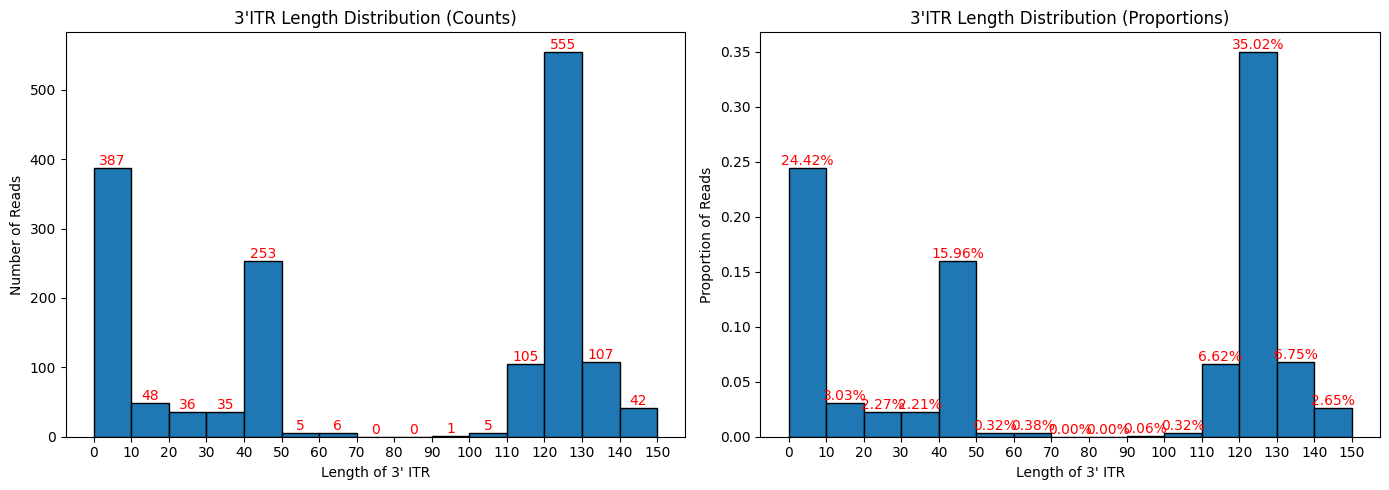

In [23]:
# distribution dbc 3' aligned to WT 
bamfile = "all_data/itr_reanalysis_data/dbc_to_wt_alignment/dbc_to_wt_nopmll_final.bam"
itr_range = [2925, 3070]
dbc_nopmll_3_no_insert = count_itr_distr_no_insertions(bamfile, itr_range)

print(len(dbc_nopmll_3_no_insert))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_, _, bars = axes[0].hist(dbc_nopmll_3_no_insert, color="#1f77b4", edgecolor="black", bins=np.arange(0, 160, 10))
axes[0].bar_label(bars, color="red", labels=[count_formatter(bar.get_height()) for bar in bars])
axes[0].set_title(f"3'ITR Length Distribution (Counts)")
axes[0].set_xlabel("Length of 3' ITR")
axes[0].set_ylabel("Number of Reads")
axes[0].set_xticks(np.arange(0, 160, 10))

_, _, bars = axes[1].hist(dbc_nopmll_3_no_insert, color="#1f77b4", edgecolor="black",
                            bins=np.arange(0, 160, 10),
                            weights=np.ones(len(dbc_nopmll_3_no_insert)) / len(dbc_nopmll_3_no_insert))
axes[1].bar_label(bars, color="red", fmt='{:.2%}')
axes[1].set_title(f"3'ITR Length Distribution (Proportions)")
axes[1].set_xlabel("Length of 3' ITR")
axes[1].set_ylabel("Proportion of Reads")
axes[1].set_xticks(np.arange(0, 160, 10))
plt.tight_layout()

145


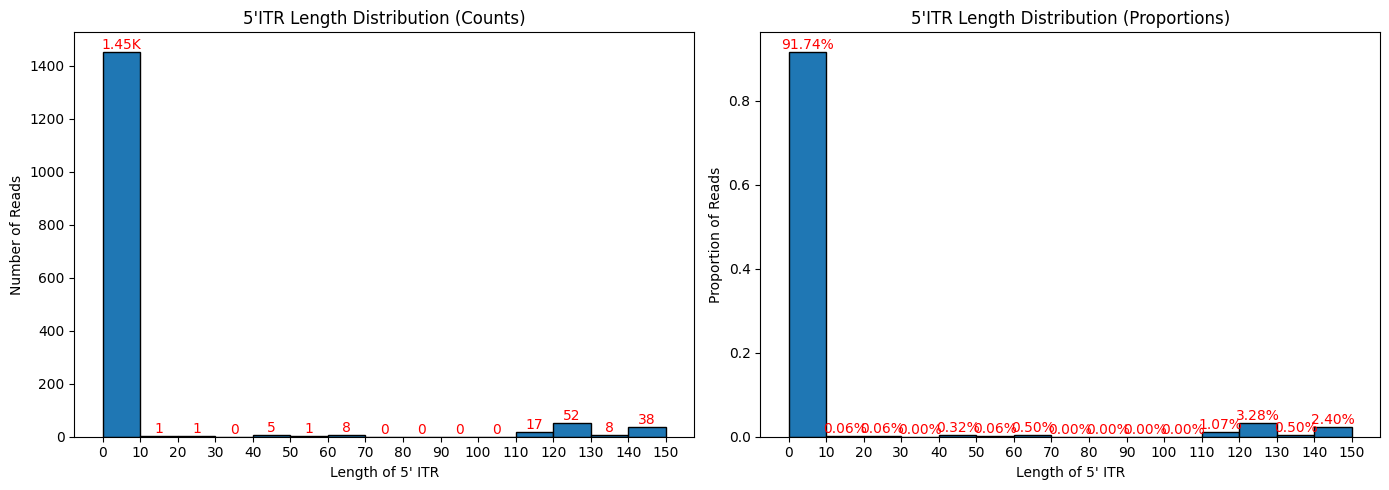

In [24]:
# distribution dbc 5' aligned to WT 
bamfile = "all_data/itr_reanalysis_data/dbc_to_wt_alignment/dbc_to_wt_nopmll_final.bam"
itr_range = [195, 340]
dbc_nopmll_5_no_insert = count_itr_distr_no_insertions(bamfile, itr_range)

print(max(dbc_nopmll_5_no_insert))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_, _, bars = axes[0].hist(dbc_nopmll_5_no_insert, color="#1f77b4", edgecolor="black", bins=np.arange(0, 160, 10))
axes[0].bar_label(bars, color="red", labels=[count_formatter(bar.get_height()) for bar in bars])
axes[0].set_title(f"5'ITR Length Distribution (Counts)")
axes[0].set_xlabel("Length of 5' ITR")
axes[0].set_ylabel("Number of Reads")
axes[0].set_xticks(np.arange(0, 160, 10))

_, _, bars = axes[1].hist(dbc_nopmll_5_no_insert, color="#1f77b4", edgecolor="black",
                            bins=np.arange(0, 160, 10),
                            weights=np.ones(len(dbc_nopmll_5_no_insert)) / len(dbc_nopmll_5_no_insert))
axes[1].bar_label(bars, color="red", fmt='{:.2%}')
axes[1].set_title(f"5'ITR Length Distribution (Proportions)")
axes[1].set_xlabel("Length of 5' ITR")
axes[1].set_ylabel("Proportion of Reads")
axes[1].set_xticks(np.arange(0, 160, 10))
plt.tight_layout()

145


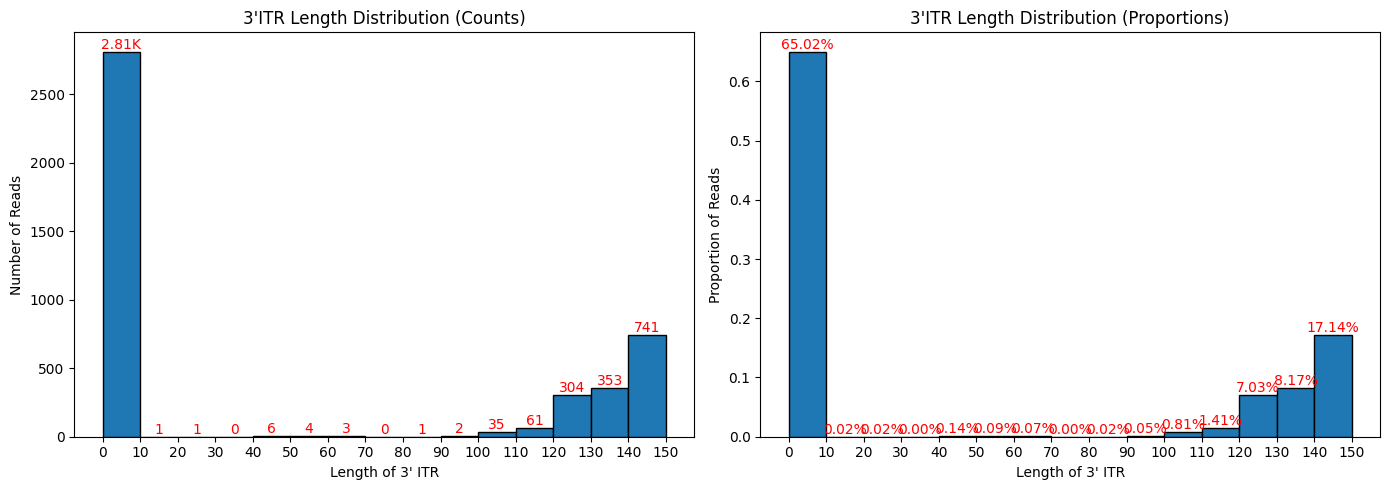

In [25]:
# distribution WT 3' aligned to WT 
bamfile = "all_data/jan_nanopore_data/77XK98_fastq/wt_nopmll_nanopore_md.bam"
itr_range = [2925, 3070]
wt_no_insertions = count_itr_distr_no_insertions(bamfile, itr_range)

print(max(wt_no_insertions))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_, _, bars = axes[0].hist(wt_no_insertions, color="#1f77b4", edgecolor="black", bins=np.arange(0, 160, 10))
axes[0].bar_label(bars, color="red", labels=[count_formatter(bar.get_height()) for bar in bars])
axes[0].set_title(f"3'ITR Length Distribution (Counts)")
axes[0].set_xlabel("Length of 3' ITR")
axes[0].set_ylabel("Number of Reads")
axes[0].set_xticks(np.arange(0, 160, 10))

_, _, bars = axes[1].hist(wt_no_insertions, color="#1f77b4", edgecolor="black",
                            bins=np.arange(0, 160, 10),
                            weights=np.ones(len(wt_no_insertions)) / len(wt_no_insertions))
axes[1].bar_label(bars, color="red", fmt='{:.2%}')
axes[1].set_title(f"3'ITR Length Distribution (Proportions)")
axes[1].set_xlabel("Length of 3' ITR")
axes[1].set_ylabel("Proportion of Reads")
axes[1].set_xticks(np.arange(0, 160, 10))
plt.tight_layout()

145


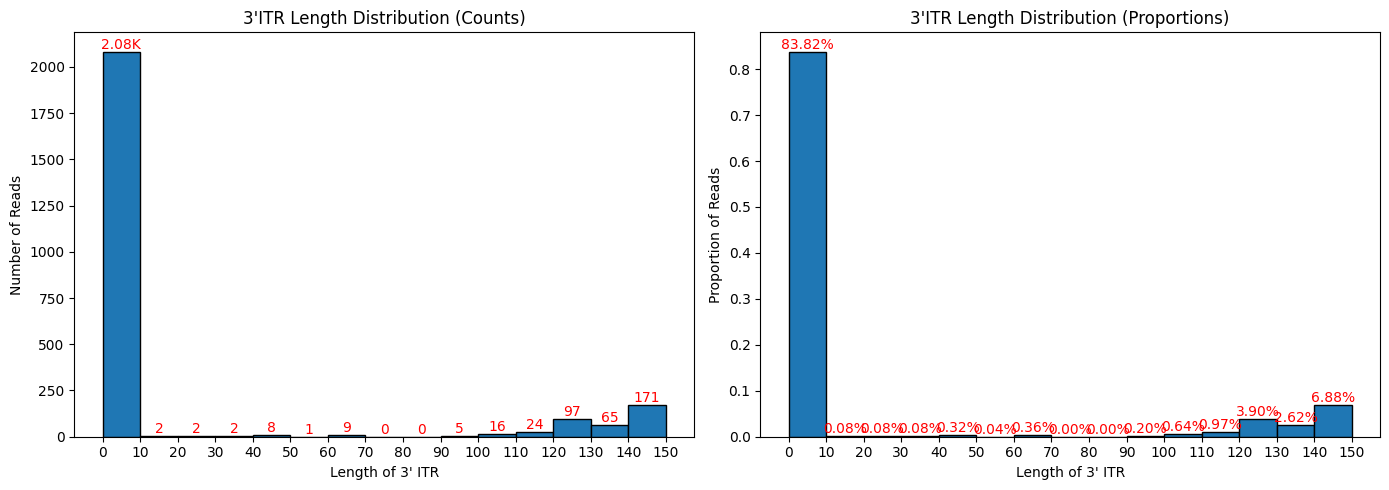

In [26]:
# distribution Hybrid 3' aligned to WT 
bamfile = "all_data/itr_reanalysis_data/hybrid_wt_alignment/hybrid_WT_final.bam"
itr_range = [2925, 3070]
hybrid_no_insertions = count_itr_distr_no_insertions(bamfile, itr_range)

print(max(hybrid_no_insertions))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_, _, bars = axes[0].hist(hybrid_no_insertions, color="#1f77b4", edgecolor="black", bins=np.arange(0, 160, 10))
axes[0].bar_label(bars, color="red", labels=[count_formatter(bar.get_height()) for bar in bars])
axes[0].set_title(f"3'ITR Length Distribution (Counts)")
axes[0].set_xlabel("Length of 3' ITR")
axes[0].set_ylabel("Number of Reads")
axes[0].set_xticks(np.arange(0, 160, 10))

_, _, bars = axes[1].hist(hybrid_no_insertions, color="#1f77b4", edgecolor="black",
                            bins=np.arange(0, 160, 10),
                            weights=np.ones(len(hybrid_no_insertions)) / len(hybrid_no_insertions))
axes[1].bar_label(bars, color="red", fmt='{:.2%}')
axes[1].set_title(f"3'ITR Length Distribution (Proportions)")
axes[1].set_xlabel("Length of 3' ITR")
axes[1].set_ylabel("Proportion of Reads")
axes[1].set_xticks(np.arange(0, 160, 10))
plt.tight_layout()

# With Insertions

In [4]:
# how many read bases (including insertions, excluding mismatches) map to the region
def count_itr_distr_with_insertions(bamfile: str, itr_range: list) -> list:
    final_lengths = []
    bases = []
    bam = pysam.AlignmentFile(bamfile)
    for read in bam.fetch():
            aligned_bases = 0
            last_ref_pos = None
            pairs = read.get_aligned_pairs(matches_only=False, with_seq=True)
            # normal aligned base
            for query_pos, ref_pos, base in pairs:
                #query_pos = position in read, ref_pos = position in reference
                bases.append(base)
                #skips deletions, which would be in query_pos = None and ref_pos = not None
                if ref_pos is not None:
                    last_ref_pos = ref_pos 
                
                    if itr_range[0] <= ref_pos < itr_range[1]:
                        aligned_bases += 1
                    
                # Insertion base
                elif ref_pos is None and query_pos is not None:   #extra base not in reference
                # assign insertion to last seen reference position
                    if last_ref_pos is not None and itr_range[0] <= last_ref_pos < itr_range[1]:
                        if base is None or base.islower():
                            continue
                        else:
                            aligned_bases += 1
            final_lengths.append(aligned_bases)
    return final_lengths

74.76845425867508


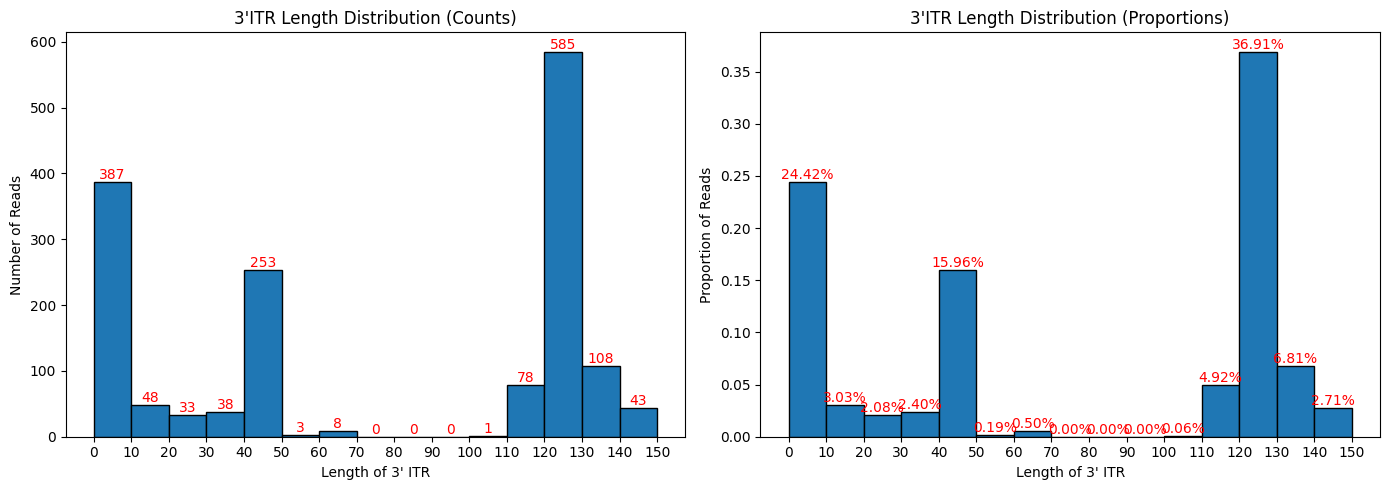

In [28]:
# distribution dbc 3' aligned to WT 
bamfile = "all_data/itr_reanalysis_data/dbc_to_wt_alignment/dbc_to_wt_nopmll_final.bam"
itr_range = [2925, 3070]
dbc_nopmll_3 = count_itr_distr_with_insertions(bamfile, itr_range)

print(np.mean(dbc_nopmll_3))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_, _, bars = axes[0].hist(dbc_nopmll_3, color="#1f77b4", edgecolor="black", bins=np.arange(0, 160, 10))
axes[0].bar_label(bars, color="red", labels=[count_formatter(bar.get_height()) for bar in bars])
axes[0].set_title(f"3'ITR Length Distribution (Counts)")
axes[0].set_xlabel("Length of 3' ITR")
axes[0].set_ylabel("Number of Reads")
axes[0].set_xticks(np.arange(0, 160, 10))

_, _, bars = axes[1].hist(dbc_nopmll_3, color="#1f77b4", edgecolor="black",
                            bins=np.arange(0, 160, 10),
                            weights=np.ones(len(dbc_nopmll_3)) / len(dbc_nopmll_3))
axes[1].bar_label(bars, color="red", fmt='{:.2%}')
axes[1].set_title(f"3'ITR Length Distribution (Proportions)")
axes[1].set_xlabel("Length of 3' ITR")
axes[1].set_ylabel("Proportion of Reads")
axes[1].set_xticks(np.arange(0, 160, 10))
plt.tight_layout()

145


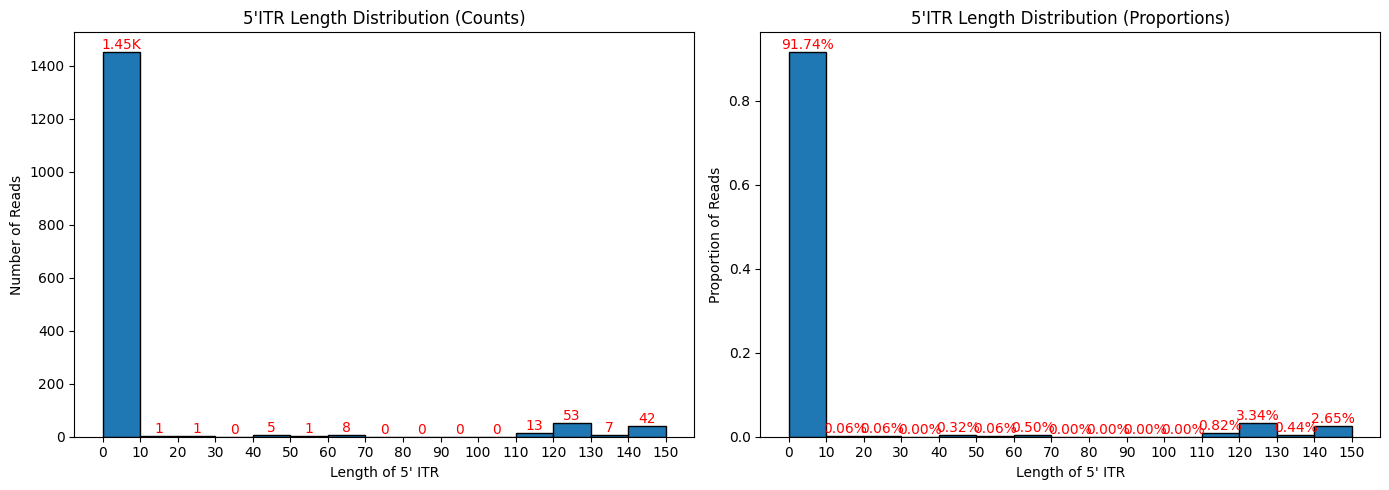

In [11]:
    # distribution dbc 5' aligned to WT 
bamfile = "all_data/itr_reanalysis_data/dbc_to_wt_alignment/dbc_to_wt_nopmll_final.bam"
itr_range = [195, 340]
dbc_nopmll_5 = count_itr_distr_with_insertions(bamfile, itr_range)

print(max(dbc_nopmll_5))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_, _, bars = axes[0].hist(dbc_nopmll_5, color="#1f77b4", edgecolor="black", bins=np.arange(0, 160, 10))
axes[0].bar_label(bars, color="red", labels=[count_formatter(bar.get_height()) for bar in bars])
axes[0].set_title(f"5'ITR Length Distribution (Counts)")
axes[0].set_xlabel("Length of 5' ITR")
axes[0].set_ylabel("Number of Reads")
axes[0].set_xticks(np.arange(0, 160, 10))

_, _, bars = axes[1].hist(dbc_nopmll_5, color="#1f77b4", edgecolor="black",
                            bins=np.arange(0, 160, 10),
                            weights=np.ones(len(dbc_nopmll_5)) / len(dbc_nopmll_5))
axes[1].bar_label(bars, color="red", fmt='{:.2%}')
axes[1].set_title(f"5'ITR Length Distribution (Proportions)")
axes[1].set_xlabel("Length of 5' ITR")
axes[1].set_ylabel("Proportion of Reads")
axes[1].set_xticks(np.arange(0, 160, 10))
plt.tight_layout()

145


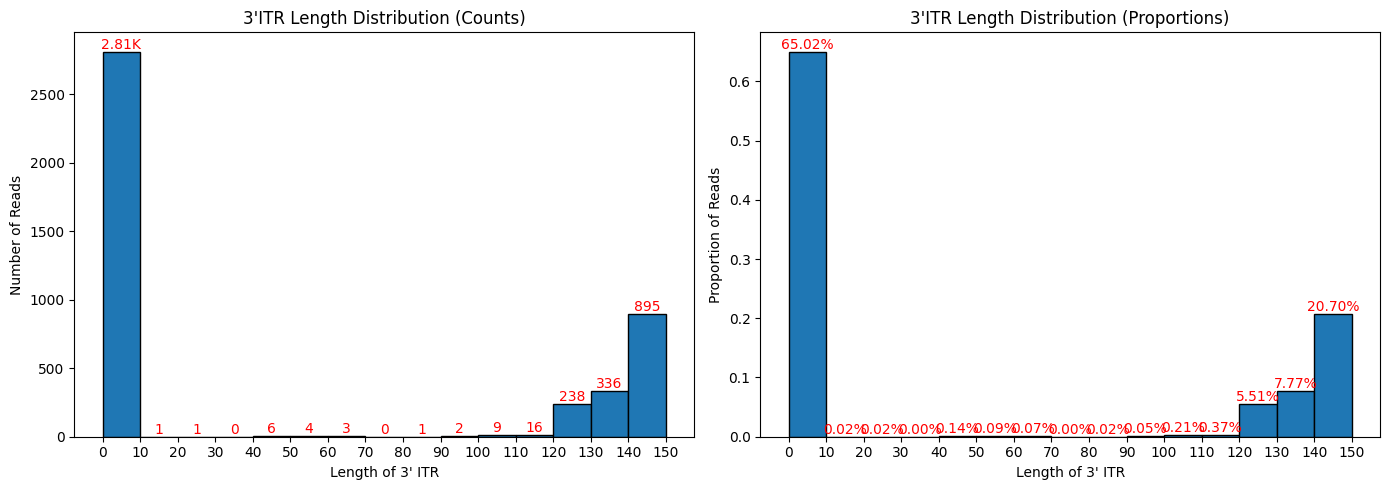

In [ ]:
# distribution WT 3' aligned to WT 
bamfile = "all_data/jan_nanopore_data/77XK98_fastq/wt_nopmll_nanopore_md.bam"
itr_range = [2925, 3070]
wt_nopmll = count_itr_distr_with_insertions(bamfile, itr_range)

print(max(wt_nopmll))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_, _, bars = axes[0].hist(wt_nopmll, color="#1f77b4", edgecolor="black", bins=np.arange(0, 160, 10))
axes[0].bar_label(bars, color="red", labels=[count_formatter(bar.get_height()) for bar in bars])
axes[0].set_title(f"3'ITR Length Distribution (Counts)")
axes[0].set_xlabel("Length of 3' ITR")
axes[0].set_ylabel("Number of Reads")
axes[0].set_xticks(np.arange(0, 160, 10))

_, _, bars = axes[1].hist(wt_nopmll, color="#1f77b4", edgecolor="black",
                            bins=np.arange(0, 160, 10),
                            weights=np.ones(len(wt_nopmll)) / len(wt_nopmll))
axes[1].bar_label(bars, color="red", fmt='{:.2%}')
axes[1].set_title(f"3'ITR Length Distribution (Proportions)")
axes[1].set_xlabel("Length of 3' ITR")
axes[1].set_ylabel("Proportion of Reads")
axes[1].set_xticks(np.arange(0, 160, 10))
plt.tight_layout()

145


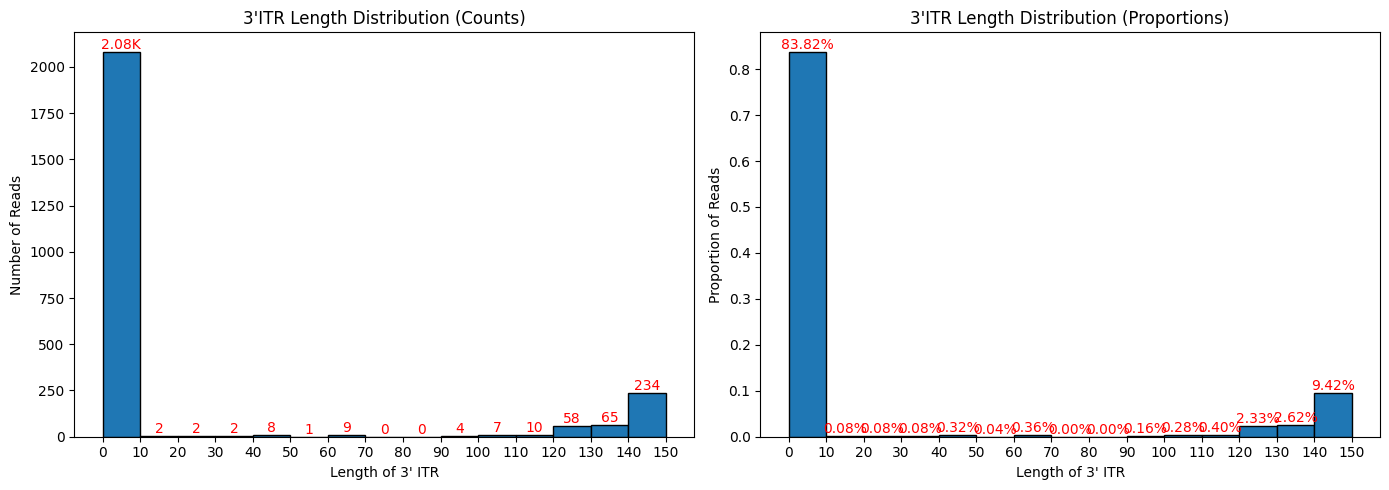

In [13]:
# distribution Hybrid 3' aligned to WT 
bamfile = "all_data/itr_reanalysis_data/hybrid_wt_alignment/hybrid_WT_final.bam"
itr_range = [2925, 3070]
hybrid_nopmll = count_itr_distr_with_insertions(bamfile, itr_range)

print(max(hybrid_nopmll))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_, _, bars = axes[0].hist(hybrid_nopmll, color="#1f77b4", edgecolor="black", bins=np.arange(0, 160, 10))
axes[0].bar_label(bars, color="red", labels=[count_formatter(bar.get_height()) for bar in bars])
axes[0].set_title(f"3'ITR Length Distribution (Counts)")
axes[0].set_xlabel("Length of 3' ITR")
axes[0].set_ylabel("Number of Reads")
axes[0].set_xticks(np.arange(0, 160, 10))

_, _, bars = axes[1].hist(hybrid_nopmll, color="#1f77b4", edgecolor="black",
                            bins=np.arange(0, 160, 10),
                            weights=np.ones(len(hybrid_nopmll)) / len(hybrid_nopmll))
axes[1].bar_label(bars, color="red", fmt='{:.2%}')
axes[1].set_title(f"3'ITR Length Distribution (Proportions)")
axes[1].set_xlabel("Length of 3' ITR")
axes[1].set_ylabel("Proportion of Reads")
axes[1].set_xticks(np.arange(0, 160, 10))
plt.tight_layout()

# Without Insertions

In [14]:
repaired_dbc_3 = 0
for i in dbc_nopmll_3_no_insert:
    if i > 111 and i <= 121:
        repaired_dbc_3 += 1
perc_repaired = round(repaired_dbc_3 / len(dbc_nopmll_3_no_insert) * 100, 2)
print(f"{perc_repaired}% dbc_nopmll 3'itr without insertions with read lengths between 111 and 121 bp")
repaired_dbc_3_145 = 0
for i in dbc_nopmll_3_no_insert:
    if i > 111 and i <= 145:
        repaired_dbc_3_145 += 1
perc_repaired_145 = round(repaired_dbc_3_145 / len(dbc_nopmll_3_no_insert) * 100, 2)
print(f"{perc_repaired_145}% dbc_nopmll 3'itr without insertions with read lengths between 111 and 145 bp")

9.21% dbc_nopmll 3'itr without insertions with read lengths between 111 and 121 bp
50.91% dbc_nopmll 3'itr without insertions with read lengths between 111 and 145 bp


In [15]:
repaired_dbc_5 = 0
for i in dbc_nopmll_5_no_insert:
    if i > 111 and i <= 118:
        repaired_dbc_5 += 1
perc_repaired = round(repaired_dbc_5 / len(dbc_nopmll_5_no_insert) * 100, 2)
print(f"{perc_repaired}% dbc_nopmll 5'itr without insertions with read lengths between 111 and 118 bp")
repaired_dbc_5_145 = 0
for i in dbc_nopmll_5_no_insert:
    if i > 111 and i <= 145:
        repaired_dbc_5_145 += 1
perc_repaired_145 = round(repaired_dbc_5_145 / len(dbc_nopmll_5_no_insert) * 100, 2)
print(f"{perc_repaired_145}% dbc_nopmll 5'itr without insertions with read lengths between 111 and 145 bp")

1.01% dbc_nopmll 5'itr without insertions with read lengths between 111 and 118 bp
7.19% dbc_nopmll 5'itr without insertions with read lengths between 111 and 145 bp


In [16]:
repaired_hybrid_3 = 0
for i in hybrid_no_insertions:
    if i > 104 and i <= 145:
        repaired_hybrid_3 += 1

perc_repaired_145 = round(repaired_hybrid_3 / len(hybrid_no_insertions) * 100, 2)
print(f"{perc_repaired_145}% hybrid 3'itr without insertions with read lengths between 104 and 145 bp")

14.89% hybrid 3'itr without insertions with read lengths between 104 and 145 bp


# With Insertions

In [17]:
repaired_dbc_3 = 0
for i in dbc_nopmll_3:
    if i > 111 and i <= 121:
        repaired_dbc_3 += 1
perc_repaired = round(repaired_dbc_3 / len(dbc_nopmll_3) * 100, 2)
print(f"{perc_repaired}% dbc_nopmll 3'itr with insertions with read lengths between 111 and 121 bp")
repaired_dbc_3_145 = 0
for i in dbc_nopmll_3:
    if i > 111 and i <= 145:
        repaired_dbc_3_145 += 1
perc_repaired_145 = round(repaired_dbc_3_145 / len(dbc_nopmll_3) * 100, 2)
print(f"{perc_repaired_145}% dbc_nopmll 3'itr with insertions with read lengths between 111 and 145 bp")

7.32% dbc_nopmll 3'itr with insertions with read lengths between 111 and 121 bp
51.36% dbc_nopmll 3'itr with insertions with read lengths between 111 and 145 bp


In [18]:
repaired_dbc_5 = 0
for i in dbc_nopmll_5:
    if i > 111 and i <= 118:
        repaired_dbc_5 += 1
perc_repaired = round(repaired_dbc_5 / len(dbc_nopmll_5) * 100, 2)
print(f"{perc_repaired}% dbc_nopmll 5'itr with insertions with read lengths between 111 and 118 bp")
repaired_dbc_5_145 = 0
for i in dbc_nopmll_5:
    if i > 111 and i <= 145:
        repaired_dbc_5_145 += 1
perc_repaired_145 = round(repaired_dbc_5_145 / len(dbc_nopmll_5) * 100, 2)
print(f"{perc_repaired_145}% dbc_nopmll 5'itr with insertions with read lengths between 111 and 145 bp")

0.76% dbc_nopmll 5'itr with insertions with read lengths between 111 and 118 bp
7.19% dbc_nopmll 5'itr with insertions with read lengths between 111 and 145 bp


In [19]:
repaired_hybrid_3 = 0
for i in hybrid_nopmll:
    if i > 104 and i <= 145:
        repaired_hybrid_3 += 1

perc_repaired_145 = round(repaired_hybrid_3 / len(hybrid_nopmll) * 100, 2)
print(f"{perc_repaired_145}% hybrid 3'itr with insertions with read lengths between 104 and 145 bp")


14.93% hybrid 3'itr with insertions with read lengths between 104 and 145 bp


# Foward and Reverse Strands

In [9]:
# PLOT CODE

def plot_strands(distribution, itr_type):
    print(np.mean(distribution))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    _, _, bars = axes[0].hist(distribution, color="#1f77b4", edgecolor="black", bins=np.arange(0, 160, 10))
    axes[0].bar_label(bars, color="red", labels=[count_formatter(bar.get_height()) for bar in bars])
    axes[0].set_title(f"{itr_type}'ITR Length Distribution (Counts)")
    axes[0].set_xlabel(f"Length of {itr_type}' ITR")
    axes[0].set_ylabel("Number of Reads")
    axes[0].set_xticks(np.arange(0, 160, 10))

    _, _, bars = axes[1].hist(distribution, color="#1f77b4", edgecolor="black",
                                bins=np.arange(0, 160, 10),
                                weights=np.ones(len(distribution)) / len(dbc_nopmll_3_reverse))
    axes[1].bar_label(bars, color="red", fmt='{:.2%}')
    axes[1].set_title(f"{itr_type}'ITR Length Distribution (Proportions)")
    axes[1].set_xlabel(f"Length of {itr_type}' ITR")
    axes[1].set_ylabel("Proportion of Reads")
    axes[1].set_xticks(np.arange(0, 160, 10))
    plt.tight_layout()

103.19812426729192


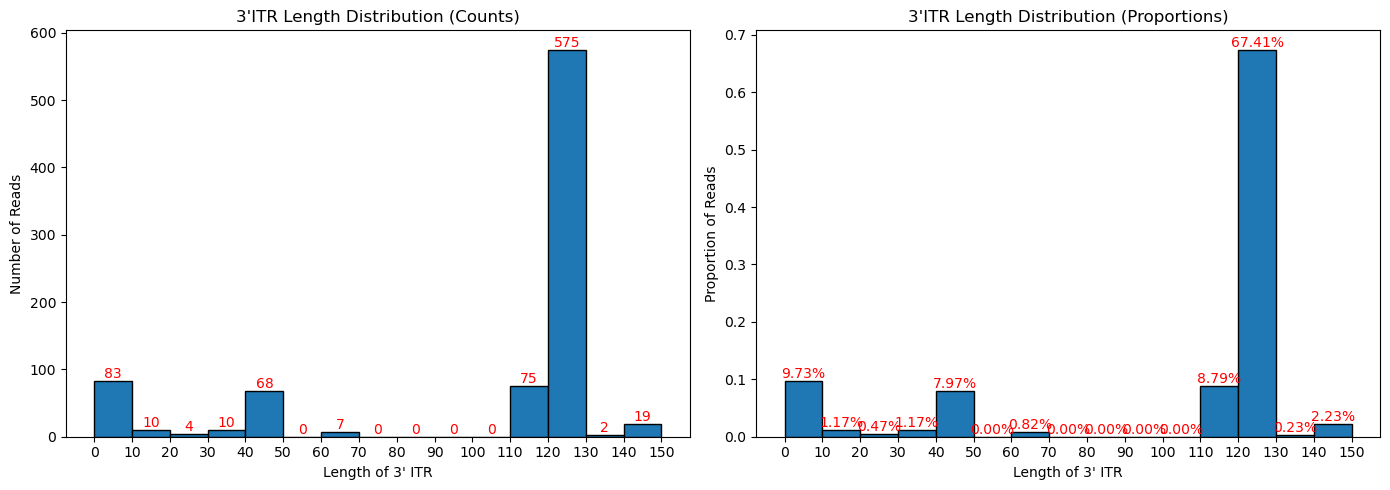

In [ ]:
# distribution dbc 3' aligned to WT forward
bamfile = "all_data/sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_forward.bam"
itr_range = [2925, 3070]
dbc_nopmll_3_reverse = count_itr_distr_with_insertions(bamfile, itr_range)
itr_type = '3'
plot_strands(dbc_nopmll_3_reverse, itr_type)

41.63934426229508


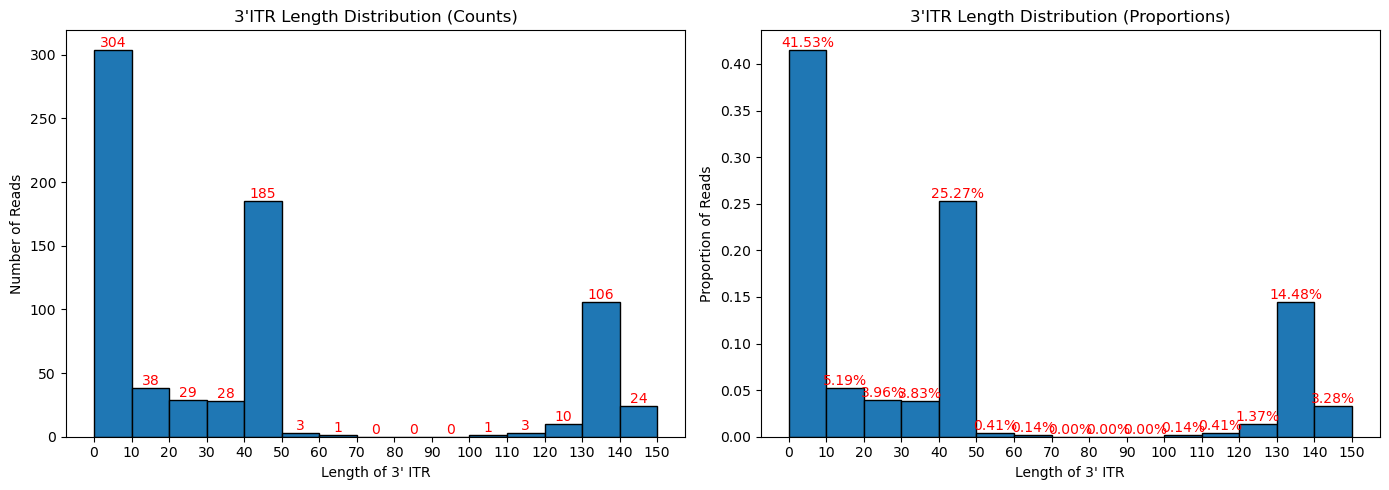

In [12]:
# distribution dbc 3' aligned to WT reverse
bamfile = "all_data/sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_reverse.bam"
itr_range = [2925, 3070]
dbc_nopmll_3_reverse = count_itr_distr_with_insertions(bamfile, itr_range)
itr_type = '3'
plot_strands(dbc_nopmll_3_reverse, itr_type)

6.083235638921454


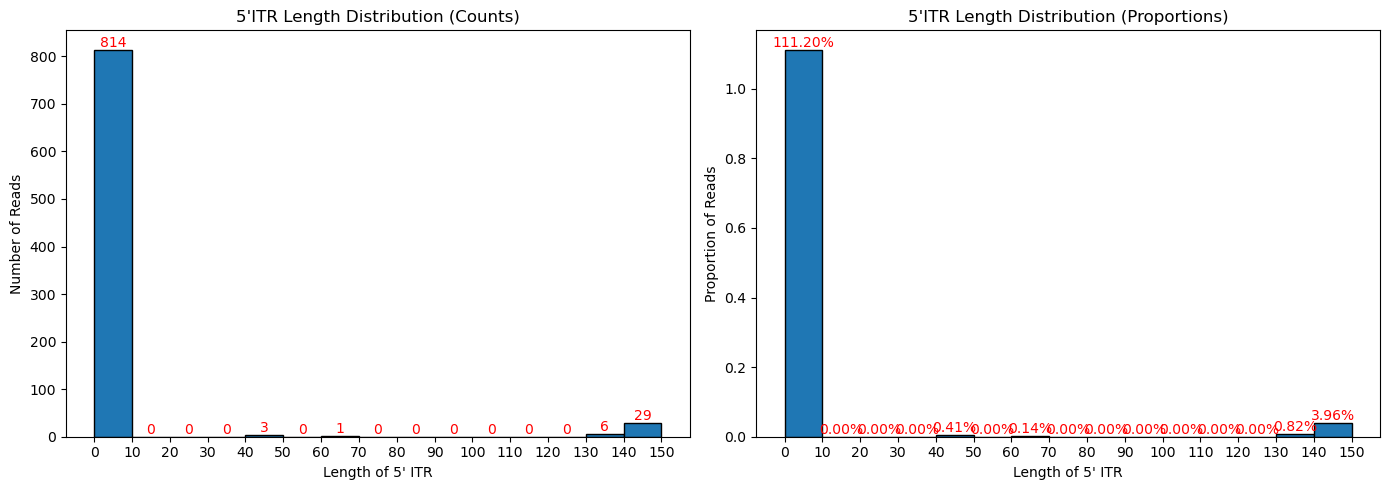

In [13]:
    # distribution dbc 5' aligned to WT forward
bamfile = "all_data/sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_forward.bam"
itr_range = [195, 340]
dbc_nopmll_5 = count_itr_distr_with_insertions(bamfile, itr_range)
itr_type = '5'
plot_strands(dbc_nopmll_5, itr_type)

14.651639344262295


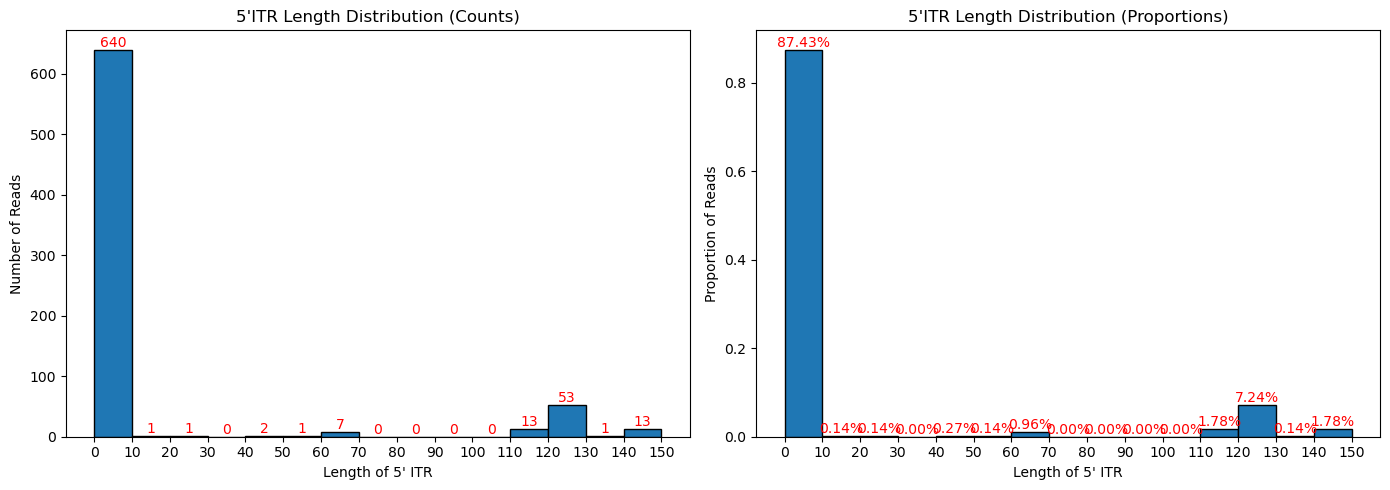

In [14]:
    # distribution dbc 5' aligned to WT reverse
bamfile = "all_data/sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_reverse.bam"
itr_range = [195, 340]
dbc_nopmll_5 = count_itr_distr_with_insertions(bamfile, itr_range)
itr_type = '5'
plot_strands(dbc_nopmll_5, itr_type)

21.15836371000405


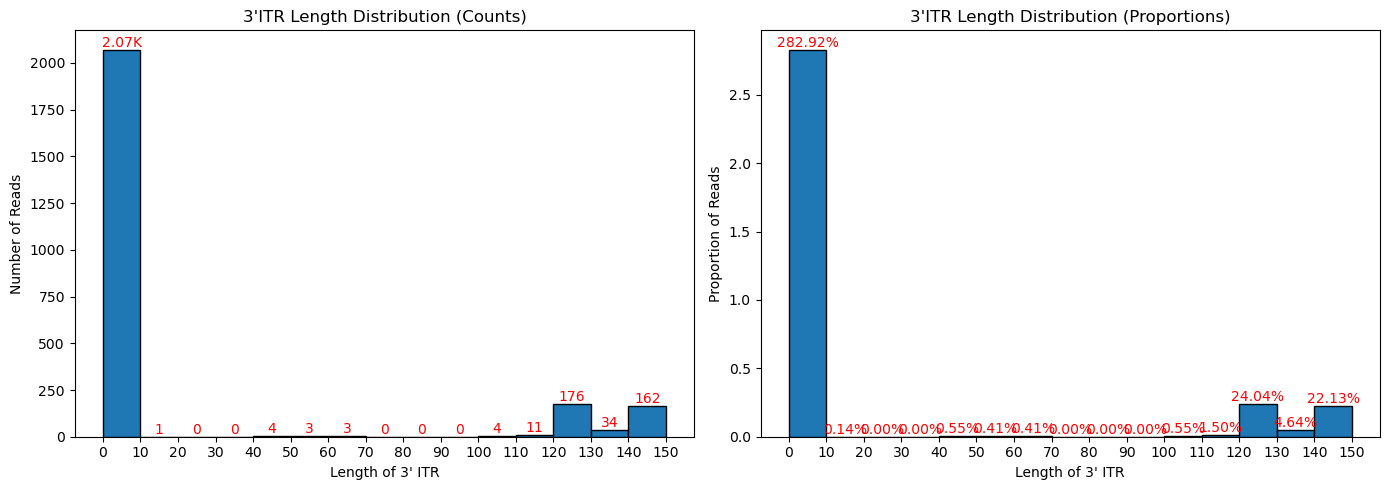

In [17]:
# distribution WT 3' aligned to forward
bamfile = "all_data/sense_strand_analysis/wt/wt_forward.bam"
itr_range = [2925, 3070]
wt_nopmll = count_itr_distr_with_insertions(bamfile, itr_range)
itr_type = '3'
plot_strands(wt_nopmll, itr_type)

84.06957928802589


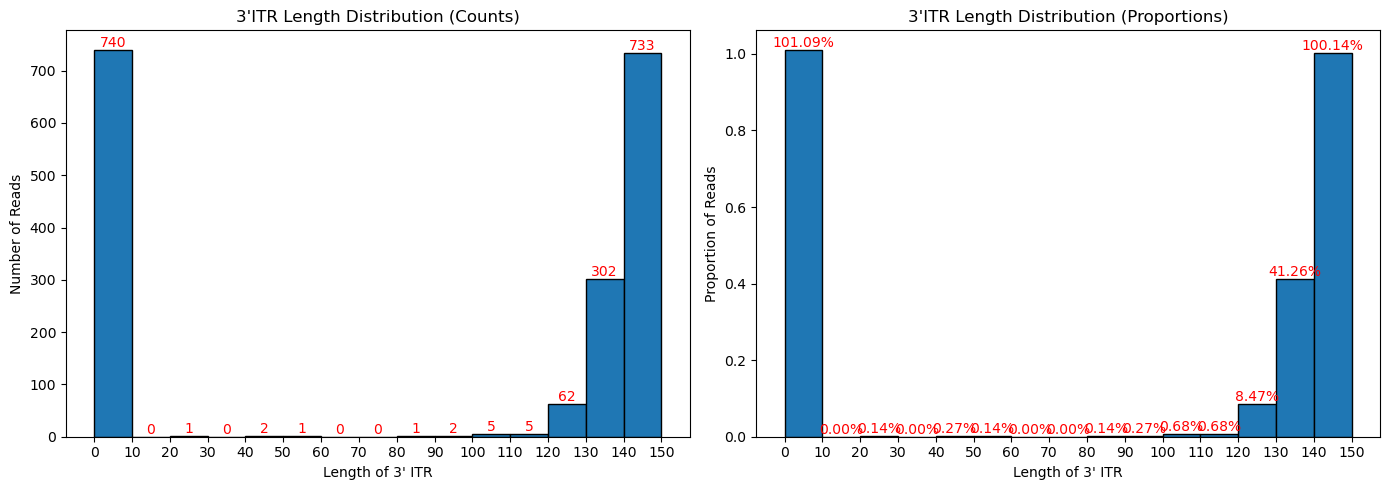

In [18]:
# distribution WT 3' aligned to reverse
bamfile = "all_data/sense_strand_analysis/wt/wt_reverse.bam"
itr_range = [2925, 3070]
wt_nopmll = count_itr_distr_with_insertions(bamfile, itr_range)
itr_type = '3'
plot_strands(wt_nopmll, itr_type)

116.9935196435804


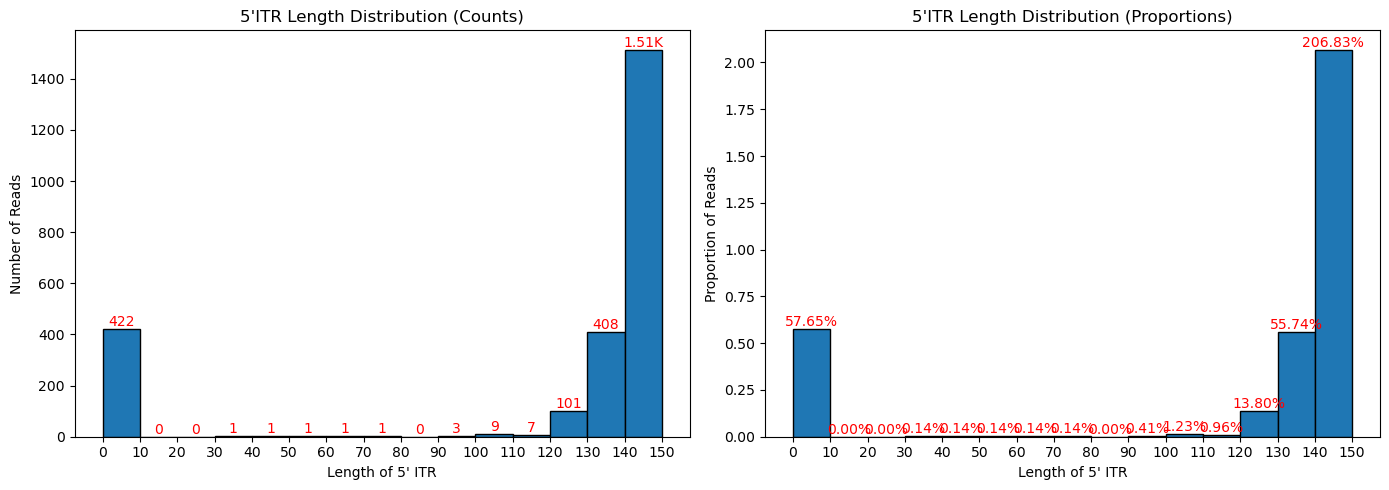

In [20]:
    # distribution WT 5' aligned to WT forward
bamfile = "all_data/sense_strand_analysis/wt/wt_forward.bam"
itr_range = [195, 340]
wt_nopmll_5 = count_itr_distr_with_insertions(bamfile, itr_range)
itr_type = '5'
plot_strands(wt_nopmll_5, itr_type)

51.85814455231931


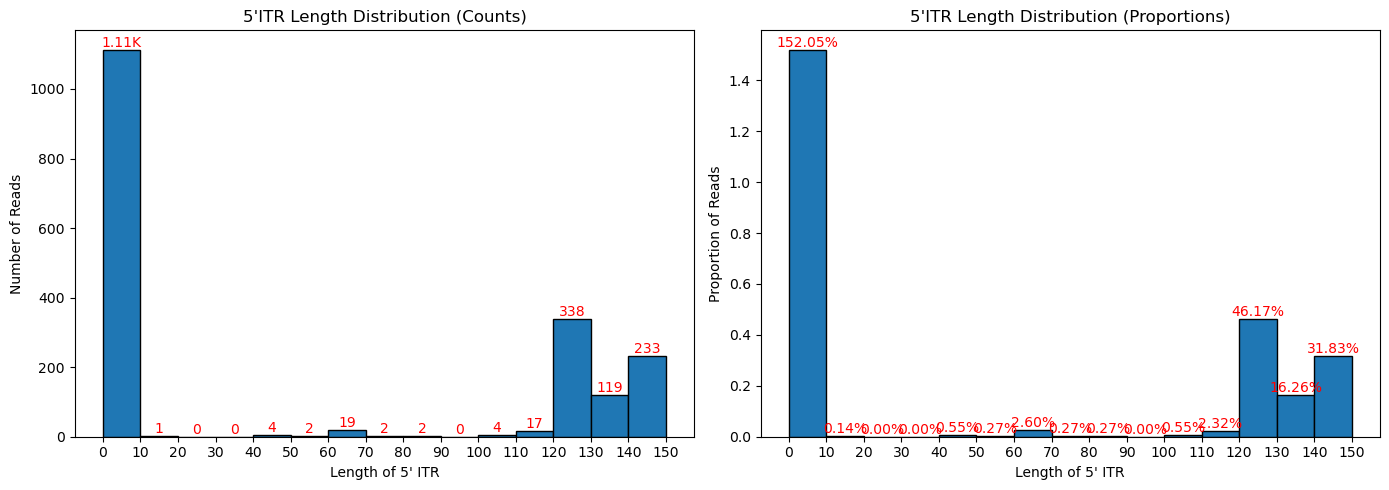

In [21]:
# distribution WT 5' aligned to WT reverse
bamfile = "all_data/sense_strand_analysis/wt/wt_reverse.bam"
itr_range = [195, 340]
wt_nopmll_5 = count_itr_distr_with_insertions(bamfile, itr_range)
itr_type = '5'
plot_strands(wt_nopmll_5, itr_type)

6.7626728110599075


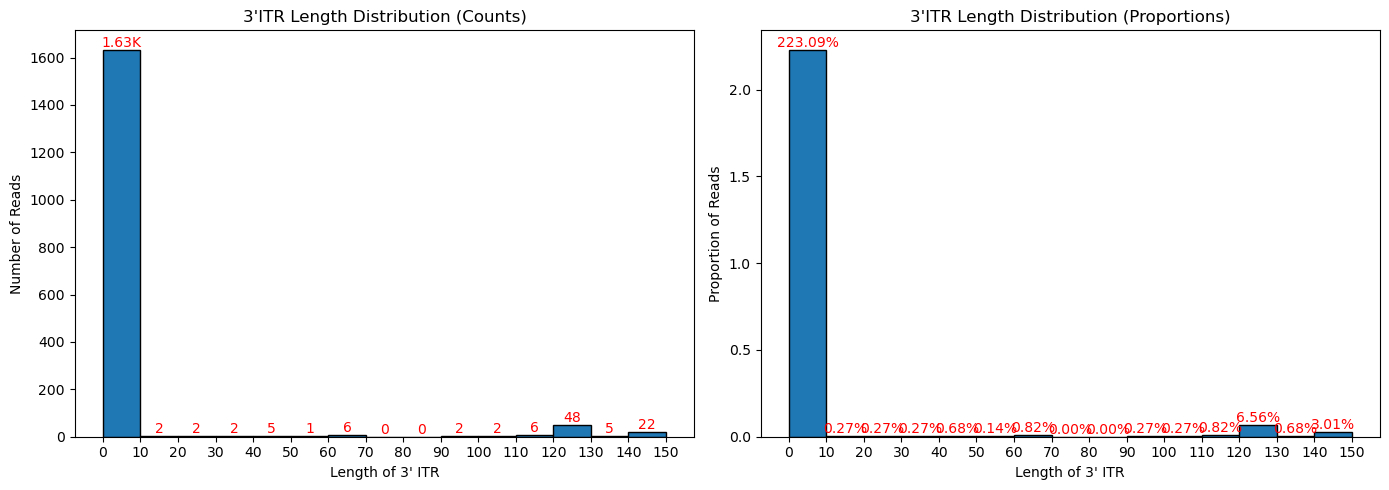

In [22]:
# distribution Hybrid 3' aligned to WT 
bamfile = "all_data/sense_strand_analysis/hybrid_wt_alignment/hybrid_wt_forward.bam"
itr_range = [2925, 3070]
hybrid_nopmll = count_itr_distr_with_insertions(bamfile, itr_range)
itr_type = '3'
plot_strands(hybrid_nopmll, itr_type)

55.25233644859813


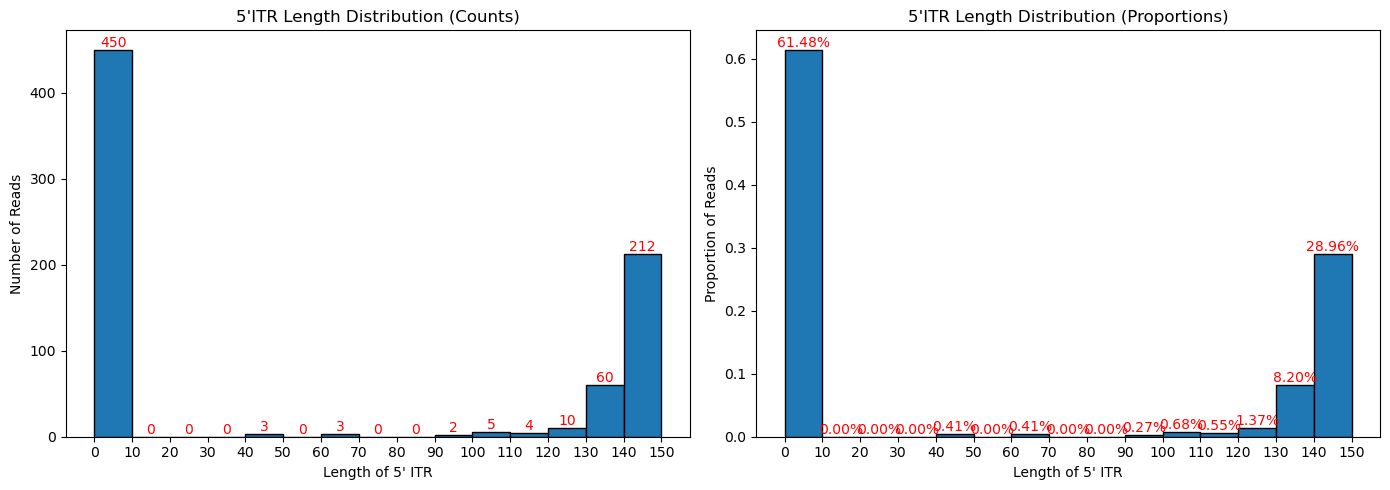

In [24]:
# distribution Hybrid 5' aligned to WT 
bamfile = "all_data/sense_strand_analysis/hybrid_wt_alignment/hybrid_wt_reverse.bam"
itr_range = [2925, 3070]
hybrid_nopmll = count_itr_distr_with_insertions(bamfile, itr_range)
itr_type = '5'
plot_strands(hybrid_nopmll, itr_type)

75.25367156208277


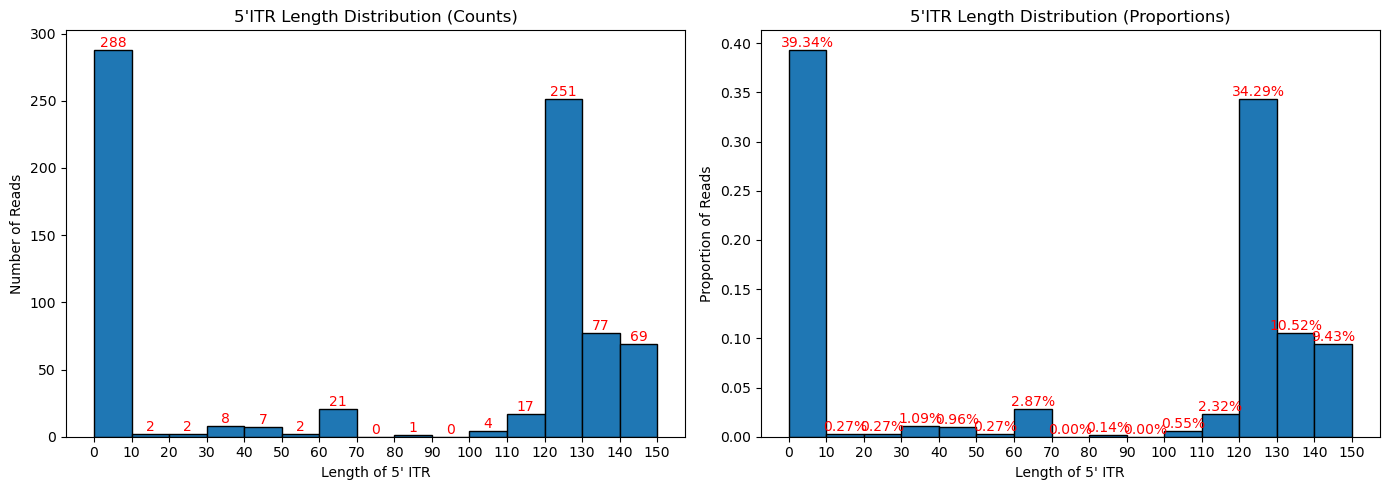

In [25]:
# distribution Hybrid 5' aligned to WT 
bamfile = "all_data/sense_strand_analysis/hybrid_wt_alignment/hybrid_wt_reverse.bam"
itr_range = [195, 340]
hybrid_nopmll = count_itr_distr_with_insertions(bamfile, itr_range)
itr_type = '5'
plot_strands(hybrid_nopmll, itr_type)

# Full Length Read Distributions

In [36]:
def count_read_lengths(bamfile: str) -> list:
    final_lengths = []
    bam = pysam.AlignmentFile(bamfile)
    reference_length = bam.lengths[0] + 1
    for read in bam.fetch():
        read_len = read.query_length
        final_lengths.append(read_len)
    return final_lengths, reference_length

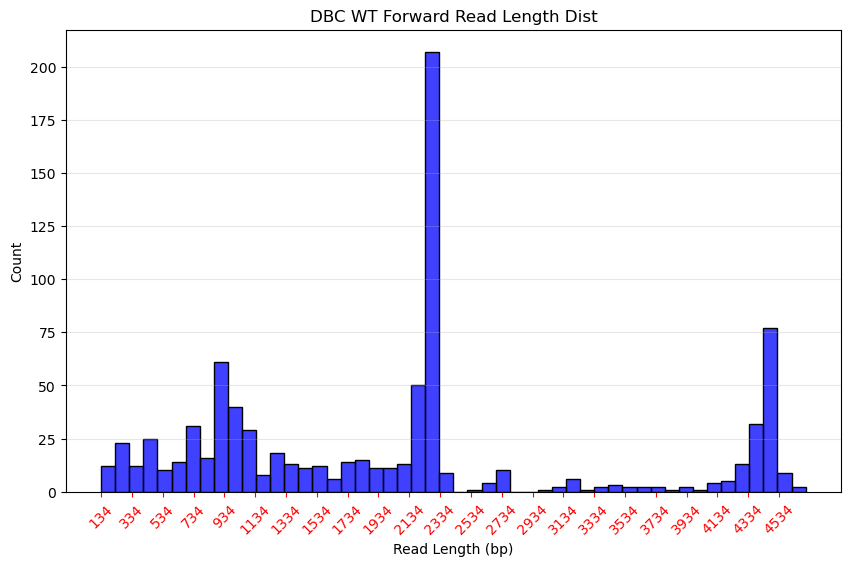

In [37]:
read_lengths = count_read_lengths("all_data/sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_forward.bam")
plt.figure(figsize=(10, 6))
sns.histplot(read_lengths[0], kde=False, bins=50, color="blue")
plt.title("DBC WT Forward Read Length Dist")
plt.xlabel("Read Length (bp)")
plt.ylabel("Count")
min_len = min(read_lengths[0])
max_len = max(read_lengths[0])
# Change 'step=10' to whatever spacing you want (e.g., every 5bp, 50bp, 500bp)
plt.tick_params(axis='x', colors='red')
plt.xticks(np.arange(start=min_len, stop=max_len + 1, step=200)) 
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

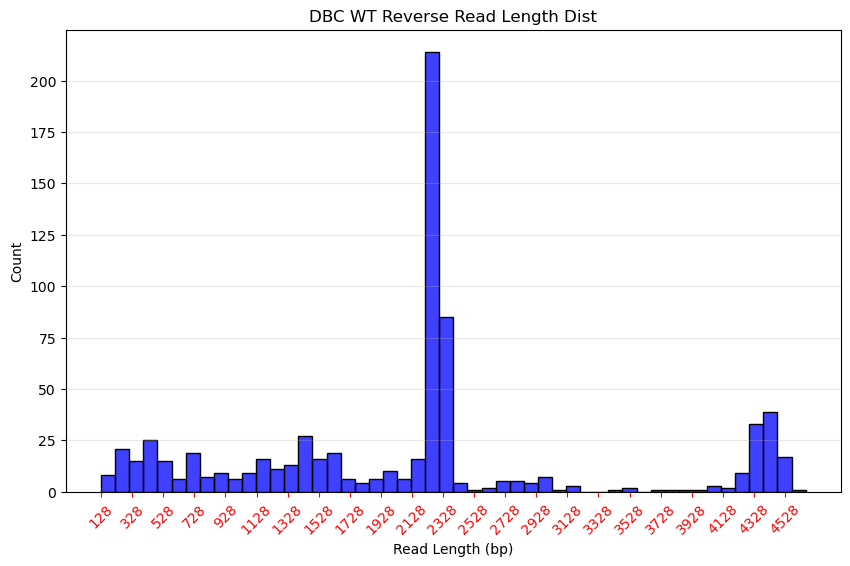

In [38]:
read_lengths = count_read_lengths("all_data/sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_reverse.bam")
plt.figure(figsize=(10, 6))
sns.histplot(read_lengths[0], kde=False, bins=50, color="blue")
plt.title("DBC WT Reverse Read Length Dist")
plt.xlabel("Read Length (bp)")
plt.ylabel("Count")
min_len = min(read_lengths[0])
max_len = max(read_lengths[0])
# Change 'step=10' to whatever spacing you want (e.g., every 5bp, 50bp, 500bp)
plt.tick_params(axis='x', colors='red')
plt.xticks(np.arange(start=min_len, stop=max_len + 1, step=200)) 
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

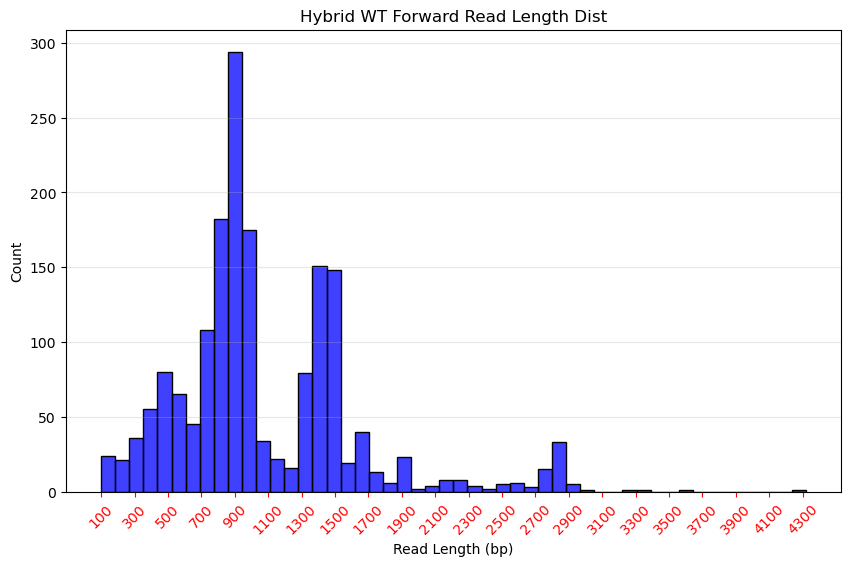

In [39]:
read_lengths = count_read_lengths("all_data/sense_strand_analysis/hybrid_wt_alignment/hybrid_wt_forward.bam")
plt.figure(figsize=(10, 6))
sns.histplot(read_lengths[0], kde=False, bins=50, color="blue")
plt.title("Hybrid WT Forward Read Length Dist")
plt.xlabel("Read Length (bp)")
plt.ylabel("Count")
min_len = min(read_lengths[0])
max_len = max(read_lengths[0])
# Change 'step=10' to whatever spacing you want (e.g., every 5bp, 50bp, 500bp)
plt.tick_params(axis='x', colors='red')
plt.xticks(np.arange(start=min_len, stop=max_len + 1, step=200)) 
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

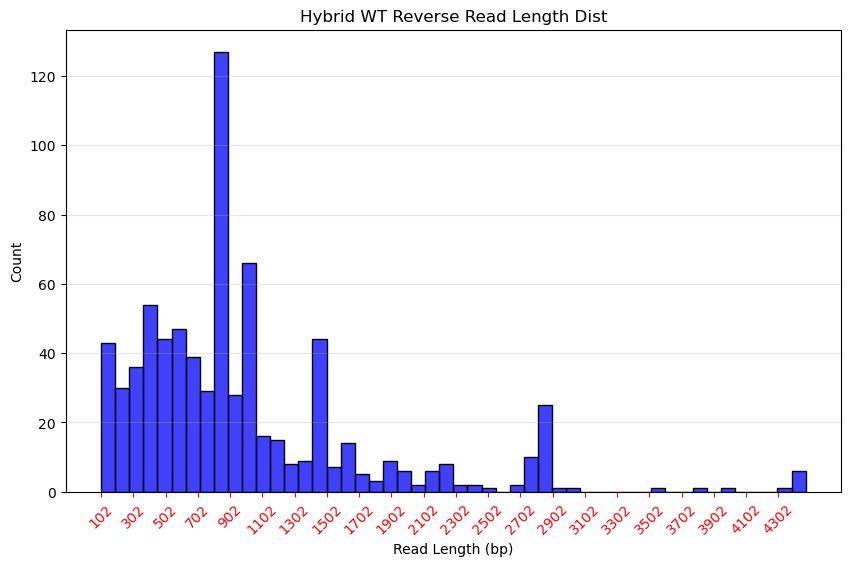

In [40]:
read_lengths = count_read_lengths("all_data/sense_strand_analysis/hybrid_wt_alignment/hybrid_wt_reverse.bam")
plt.figure(figsize=(10, 6))
sns.histplot(read_lengths[0], kde=False, bins=50, color="blue")
plt.title("Hybrid WT Reverse Read Length Dist")
plt.xlabel("Read Length (bp)")
plt.ylabel("Count")
min_len = min(read_lengths[0])
max_len = max(read_lengths[0])
# Change 'step=10' to whatever spacing you want (e.g., every 5bp, 50bp, 500bp)
plt.tick_params(axis='x', colors='red')
plt.xticks(np.arange(start=min_len, stop=max_len + 1, step=200)) 
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

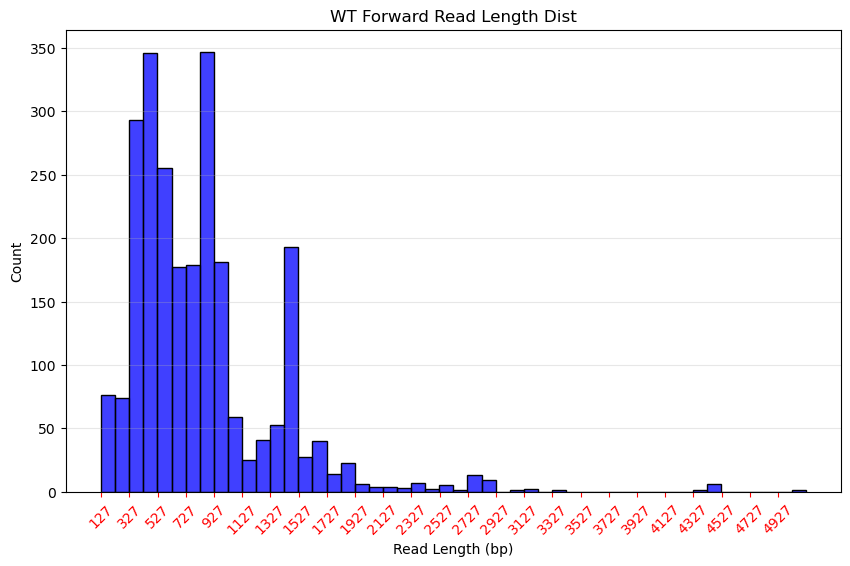

In [41]:
read_lengths = count_read_lengths("all_data/sense_strand_analysis/wt/wt_forward.bam")
plt.figure(figsize=(10, 6))
sns.histplot(read_lengths[0], kde=False, bins=50, color="blue")
plt.title("WT Forward Read Length Dist")
plt.xlabel("Read Length (bp)")
plt.ylabel("Count")
min_len = min(read_lengths[0])
max_len = max(read_lengths[0])
# Change 'step=10' to whatever spacing you want (e.g., every 5bp, 50bp, 500bp)
plt.tick_params(axis='x', colors='red')
plt.xticks(np.arange(start=min_len, stop=max_len + 1, step=200)) 
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

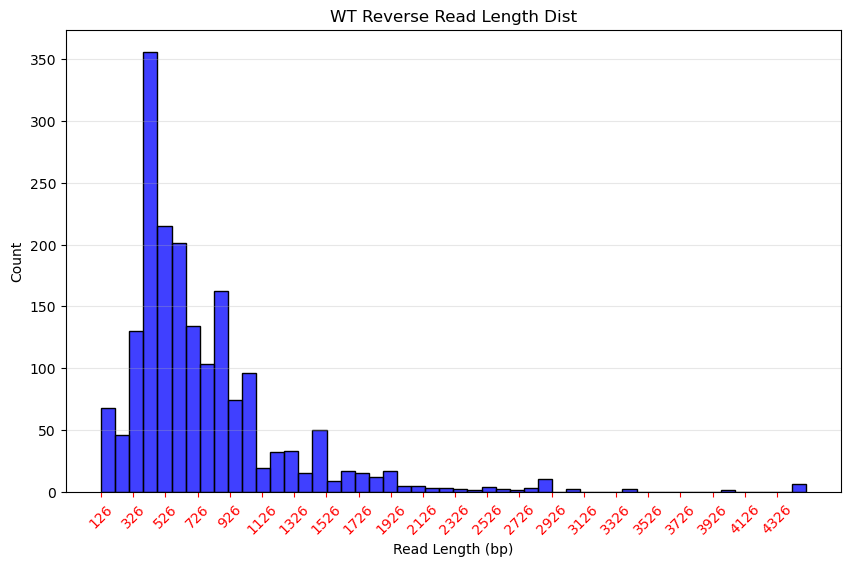

In [42]:
read_lengths = count_read_lengths("all_data/sense_strand_analysis/wt/wt_reverse.bam")
plt.figure(figsize=(10, 6))
sns.histplot(read_lengths[0], kde=False, bins=50, color="blue")
plt.title("WT Reverse Read Length Dist")
plt.xlabel("Read Length (bp)")
plt.ylabel("Count")
min_len = min(read_lengths[0])
max_len = max(read_lengths[0])
# Change 'step=10' to whatever spacing you want (e.g., every 5bp, 50bp, 500bp)
plt.tick_params(axis='x', colors='red')
plt.xticks(np.arange(start=min_len, stop=max_len + 1, step=200)) 
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Full Read Length v.s. ITR Length Scatterplot

In [45]:
def itr_and_read_len(bamfile: str, itr_range: list) -> list:
    final_full_lengths = []
    final_itr_lengths = []
    bases = []
    bam = pysam.AlignmentFile(bamfile)
    for read in bam.fetch():
            read_len = read.query_length
            final_full_lengths.append(read_len)
            aligned_bases = 0
            last_ref_pos = None
            pairs = read.get_aligned_pairs(matches_only=False, with_seq=True)
            # normal aligned base
            for query_pos, ref_pos, base in pairs:
                #query_pos = position in read, ref_pos = position in reference
                bases.append(base)
                #skips deletions, which would be in query_pos = None and ref_pos = not None
                if ref_pos is not None:
                    last_ref_pos = ref_pos 
                
                    if itr_range[0] <= ref_pos < itr_range[1]:
                        aligned_bases += 1
                    
                # Insertion base
                elif ref_pos is None and query_pos is not None:   #extra base not in reference
                # assign insertion to last seen reference position
                    if last_ref_pos is not None and itr_range[0] <= last_ref_pos < itr_range[1]:
                        if base is None or base.islower():
                            continue
                        else:
                            aligned_bases += 1
            final_itr_lengths.append(aligned_bases)
    return final_full_lengths, final_itr_lengths

Text(0.5, 1.0, "DBC WT Read vs ITR Length, 3' Forward")

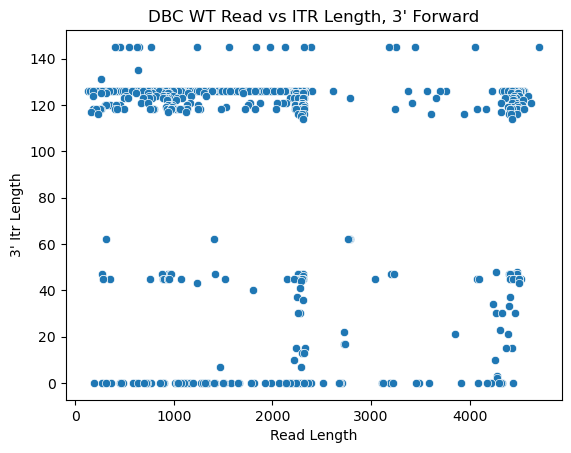

In [50]:
bamfile = "all_data/sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_forward.bam"
itr_range = [2925, 3070]
read_and_itr_lens = itr_and_read_len(bamfile, itr_range)
x = read_and_itr_lens[0]
y = read_and_itr_lens[1]
sns.scatterplot(x=x, y=y)

# Add labels (optional)
plt.xlabel("Read Length")
plt.ylabel("3' Itr Length")
plt.title("DBC WT Read vs ITR Length, 3' Forward")

Text(0.5, 1.0, "DBC WT Read vs ITR Length, 3' Reverse")

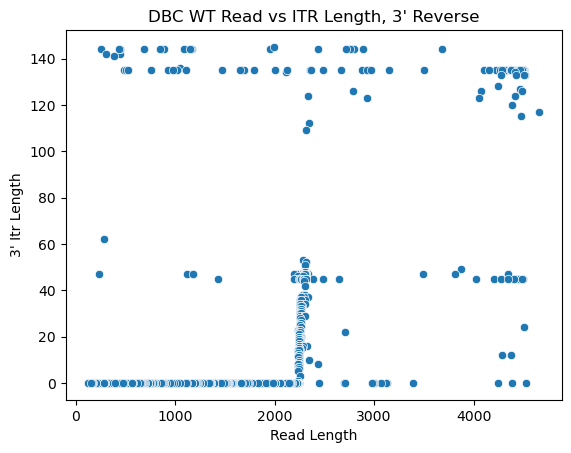

In [51]:
bamfile = "all_data/sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_reverse.bam"
itr_range = [2925, 3070]
read_and_itr_lens = itr_and_read_len(bamfile, itr_range)
x = read_and_itr_lens[0]
y = read_and_itr_lens[1]
sns.scatterplot(x=x, y=y)

# Add labels (optional)
plt.xlabel("Read Length")
plt.ylabel("3' Itr Length")
plt.title("DBC WT Read vs ITR Length, 3' Reverse")

Text(0.5, 1.0, "DBC WT Read vs ITR Length, 5' Forward")

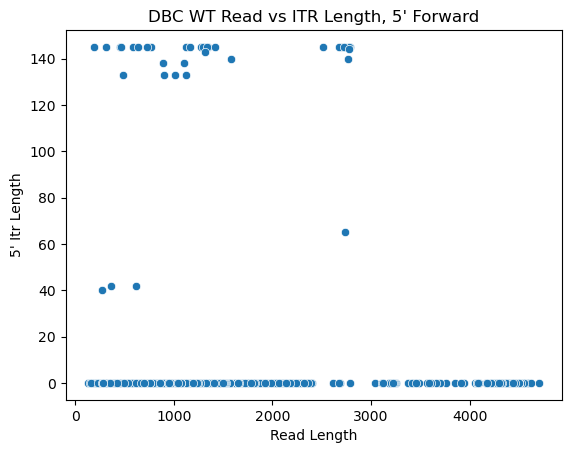

In [52]:
bamfile = "all_data/sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_forward.bam"
itr_range = [195, 340]
read_and_itr_lens = itr_and_read_len(bamfile, itr_range)
x = read_and_itr_lens[0]
y = read_and_itr_lens[1]
sns.scatterplot(x=x, y=y)

# Add labels (optional)
plt.xlabel("Read Length")
plt.ylabel("5' Itr Length")
plt.title("DBC WT Read vs ITR Length, 5' Forward")

Text(0.5, 1.0, "DBC WT Read vs ITR Length, 5' Reverse")

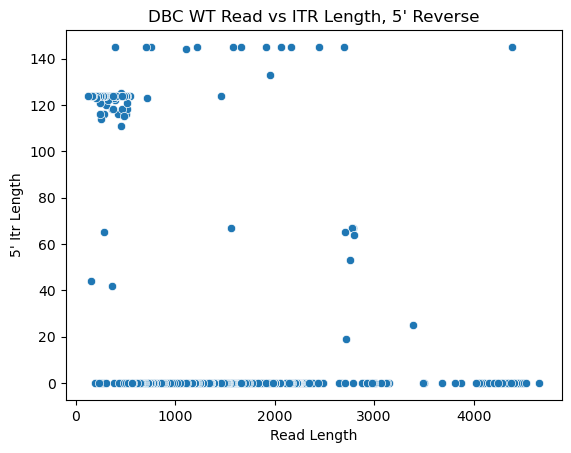

In [53]:
bamfile = "all_data/sense_strand_analysis/dbc_to_wt_alignment/dbc_wt_reverse.bam"
itr_range = [195, 340]
read_and_itr_lens = itr_and_read_len(bamfile, itr_range)
x = read_and_itr_lens[0]
y = read_and_itr_lens[1]
sns.scatterplot(x=x, y=y)

# Add labels (optional)
plt.xlabel("Read Length")
plt.ylabel("5' Itr Length")
plt.title("DBC WT Read vs ITR Length, 5' Reverse")

Text(0.5, 1.0, "Hybrid WT Read vs ITR Length, 3' Forward")

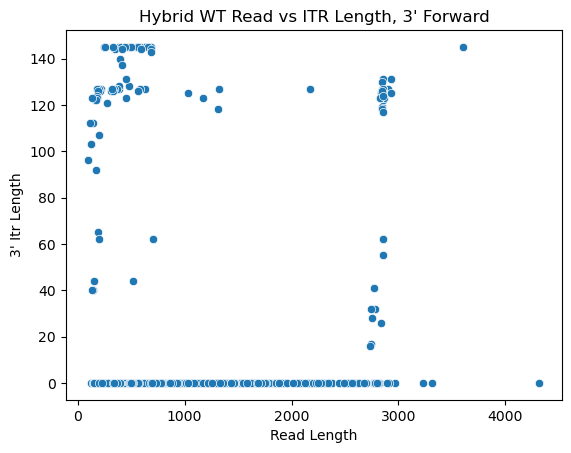

In [54]:
bamfile = "all_data/sense_strand_analysis/hybrid_wt_alignment/hybrid_WT_forward.bam"
itr_range = [2925, 3070]
read_and_itr_lens = itr_and_read_len(bamfile, itr_range)
x = read_and_itr_lens[0]
y = read_and_itr_lens[1]
sns.scatterplot(x=x, y=y)

# Add labels (optional)
plt.xlabel("Read Length")
plt.ylabel("3' Itr Length")
plt.title("Hybrid WT Read vs ITR Length, 3' Forward")

Text(0.5, 1.0, "Hybrid WT Read vs ITR Length, 3' Reverse")

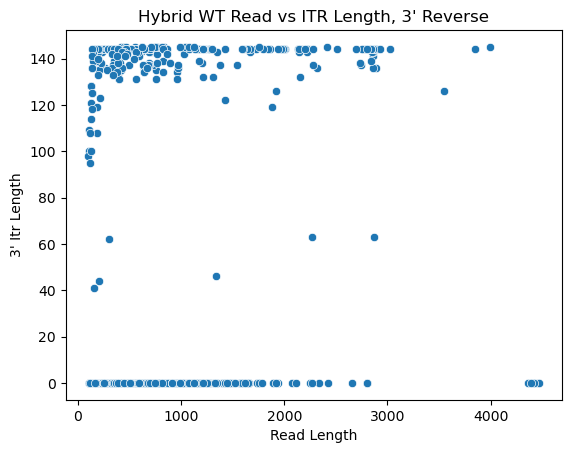

In [55]:
bamfile = "all_data/sense_strand_analysis/hybrid_wt_alignment/hybrid_WT_reverse.bam"
itr_range = [2925, 3070]
read_and_itr_lens = itr_and_read_len(bamfile, itr_range)
x = read_and_itr_lens[0]
y = read_and_itr_lens[1]
sns.scatterplot(x=x, y=y)

# Add labels (optional)
plt.xlabel("Read Length")
plt.ylabel("3' Itr Length")
plt.title("Hybrid WT Read vs ITR Length, 3' Reverse")

Text(0.5, 1.0, "Hybrid WT Read vs ITR Length, 5' Forward")

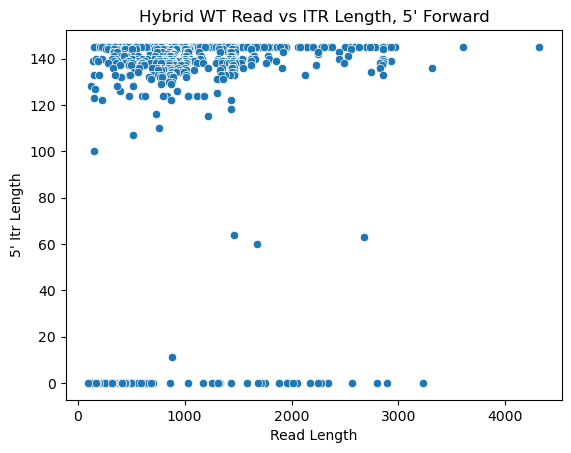

In [56]:
bamfile = "all_data/sense_strand_analysis/hybrid_wt_alignment/hybrid_WT_forward.bam"
itr_range = [195, 340]
read_and_itr_lens = itr_and_read_len(bamfile, itr_range)
x = read_and_itr_lens[0]
y = read_and_itr_lens[1]
sns.scatterplot(x=x, y=y)

# Add labels (optional)
plt.xlabel("Read Length")
plt.ylabel("5' Itr Length")
plt.title("Hybrid WT Read vs ITR Length, 5' Forward")

Text(0.5, 1.0, "Hybrid WT Read vs ITR Length, 5' Reverse")

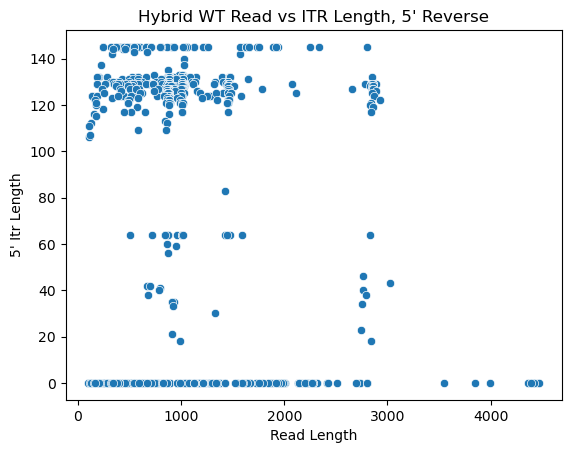

In [58]:
bamfile = "all_data/sense_strand_analysis/hybrid_wt_alignment/hybrid_WT_reverse.bam"
itr_range = [195, 340]
read_and_itr_lens = itr_and_read_len(bamfile, itr_range)
x = read_and_itr_lens[0]
y = read_and_itr_lens[1]
sns.scatterplot(x=x, y=y)

# Add labels (optional)
plt.xlabel("Read Length")
plt.ylabel("5' Itr Length")
plt.title("Hybrid WT Read vs ITR Length, 5' Reverse")

Text(0.5, 1.0, "WT Read vs ITR Length, 3' Forward")

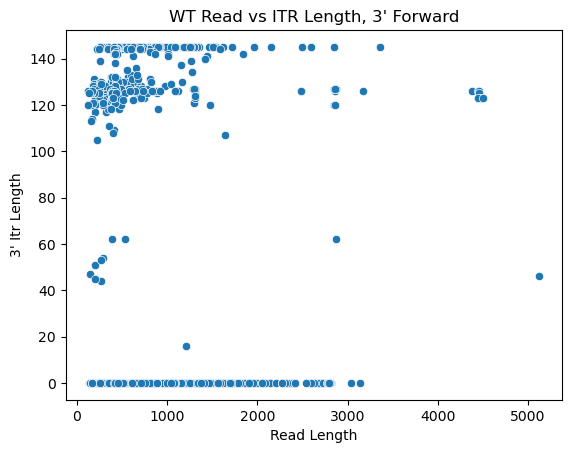

In [60]:
bamfile = "all_data/sense_strand_analysis/wt/wt_forward.bam"
itr_range = [2925, 3070]
read_and_itr_lens = itr_and_read_len(bamfile, itr_range)
x = read_and_itr_lens[0]
y = read_and_itr_lens[1]
sns.scatterplot(x=x, y=y)

# Add labels (optional)
plt.xlabel("Read Length")
plt.ylabel("3' Itr Length")
plt.title("WT Read vs ITR Length, 3' Forward")

Text(0.5, 1.0, "WT Read vs ITR Length, 3' Reverse")

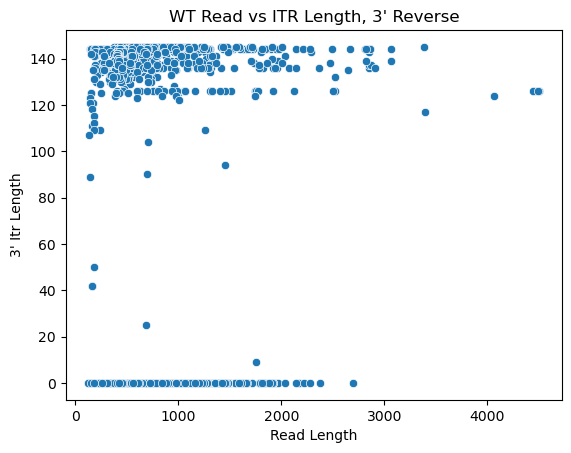

In [61]:
bamfile = "all_data/sense_strand_analysis/wt/wt_reverse.bam"
itr_range = [2925, 3070]
read_and_itr_lens = itr_and_read_len(bamfile, itr_range)
x = read_and_itr_lens[0]
y = read_and_itr_lens[1]
sns.scatterplot(x=x, y=y)

# Add labels (optional)
plt.xlabel("Read Length")
plt.ylabel("3' Itr Length")
plt.title("WT Read vs ITR Length, 3' Reverse")

Text(0.5, 1.0, "WT Read vs ITR Length, 5' Forward")

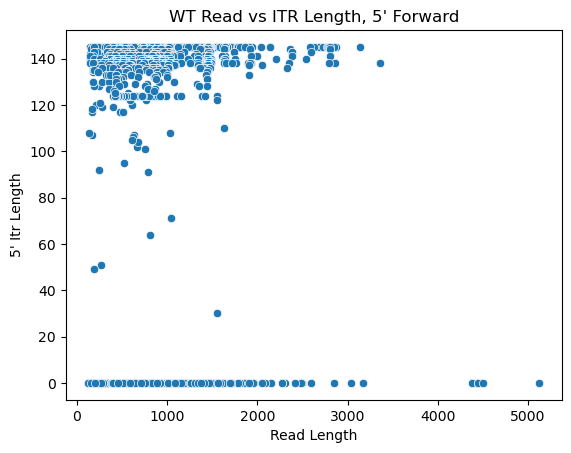

In [62]:
bamfile = "all_data/sense_strand_analysis/wt/wt_forward.bam"
itr_range = [195, 340]
read_and_itr_lens = itr_and_read_len(bamfile, itr_range)
x = read_and_itr_lens[0]
y = read_and_itr_lens[1]
sns.scatterplot(x=x, y=y)

# Add labels (optional)
plt.xlabel("Read Length")
plt.ylabel("5' Itr Length")
plt.title("WT Read vs ITR Length, 5' Forward")

Text(0.5, 1.0, "WT Read vs ITR Length, 5' Reverse")

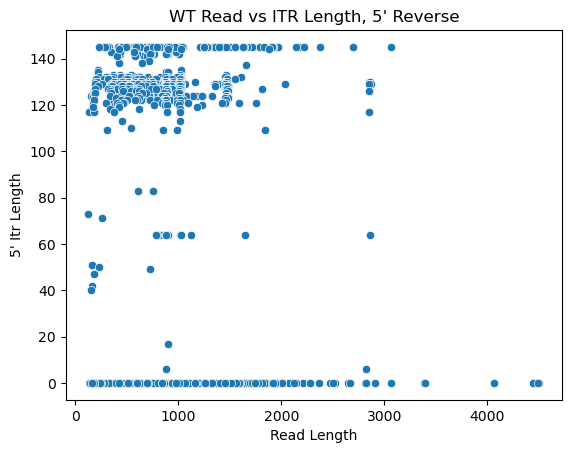

In [63]:
bamfile = "all_data/sense_strand_analysis/wt/wt_reverse.bam"
itr_range = [195, 340]
read_and_itr_lens = itr_and_read_len(bamfile, itr_range)
x = read_and_itr_lens[0]
y = read_and_itr_lens[1]
sns.scatterplot(x=x, y=y)

# Add labels (optional)
plt.xlabel("Read Length")
plt.ylabel("5' Itr Length")
plt.title("WT Read vs ITR Length, 5' Reverse")